In [1]:
!pip install yfinance

In [2]:
import yfinance as yf

aapl = yf.download(
    "AAPL",
    start="2020-01-01",
    end="2026-01-01",
    auto_adjust=False
)

aapl.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2020-01-02,72.271545,75.087502,75.150002,73.797501,74.059998,135480400
2020-01-03,71.568924,74.357498,75.144997,74.125000,74.287498,146322800
2020-01-06,72.139191,74.949997,74.989998,73.187500,73.447502,118387200
2020-01-07,71.799927,74.597504,75.224998,74.370003,74.959999,108872000
2020-01-08,72.954926,75.797501,76.110001,74.290001,74.290001,132079200


In [3]:
# Flatten the multi-level columns
aapl.columns = aapl.columns.get_level_values(0)

aapl.head()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2020-01-02,72.271545,75.087502,75.150002,73.797501,74.059998,135480400
2020-01-03,71.568924,74.357498,75.144997,74.125000,74.287498,146322800
2020-01-06,72.139191,74.949997,74.989998,73.187500,73.447502,118387200
2020-01-07,71.799927,74.597504,75.224998,74.370003,74.959999,108872000
2020-01-08,72.954926,75.797501,76.110001,74.290001,74.290001,132079200


In [4]:
aapl.shape

(1508, 6)

In [5]:
aapl.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1508 entries, 2020-01-02 to 2025-12-31
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  1508 non-null   float64
 1   Close      1508 non-null   float64
 2   High       1508 non-null   float64
 3   Low        1508 non-null   float64
 4   Open       1508 non-null   float64
 5   Volume     1508 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 82.5 KB


In [6]:
aapl.isnull().sum()

,0
Price,
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [7]:
aapl.duplicated().sum()

np.int64(0)

In [8]:
# Sort the data by closing price to identify the days with the highest closing prices.
top_close = aapl.sort_values("Close", ascending=False).head(10)

top_close

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2025-12-02,285.413116,286.190002,287.399994,282.630005,283.000000,53669500
2025-12-03,283.378662,284.149994,288.619995,283.299988,286.200012,43538700
2025-12-01,282.331512,283.100006,283.420013,276.140015,278.010010,46587700
2025-12-04,279.938019,280.700012,284.730011,278.589996,284.100006,43989100
2025-11-28,278.093048,278.850006,279.000000,275.989990,277.260010,20135600
2025-12-05,278.023224,278.779999,281.140015,278.049988,280.540009,47265800
2025-12-10,278.023224,278.779999,279.750000,276.440002,277.750000,33038300
2025-12-12,277.524567,278.279999,279.220001,276.820007,277.899994,39532900
2025-12-11,277.275269,278.029999,279.589996,273.809998,279.100006,33248000


In [9]:
# Filter trading days when AAPL's closing price was above $200.
high_price_days = aapl[aapl["Close"] > 200]

high_price_days.head(10)

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2024-06-11,205.193985,207.149994,207.160004,193.630005,193.649994,172373300
2024-06-12,211.058121,213.070007,220.199997,206.899994,207.369995,198134300
2024-06-13,212.217072,214.240005,216.750000,211.600006,214.740005,97862700
2024-06-14,210.483582,212.490005,215.169998,211.300003,213.850006,70122700
2024-06-17,214.624100,216.669998,218.949997,212.720001,213.369995,93728300
2024-06-18,212.266571,214.289993,218.630005,213.000000,217.589996,79943300
2024-06-20,207.700119,209.679993,214.240005,208.850006,213.929993,86172500
2024-06-21,205.530792,207.490005,211.889999,207.110001,210.389999,241805100
2024-06-24,206.174683,208.139999,212.699997,206.589996,207.720001,80727000


In [10]:
# Group the stock data by year and calculate key yearly statistics.
yearly_summary = aapl.groupby(aapl.index.year).agg({
    "Open": "mean",
    "High": "max",
    "Low": "min",
    "Close": "mean",
    "Volume": "mean"
})

yearly_summary

Price,Open,High,Low,Close,Volume
Date,,,,,
2020,95.267668,138.789993,53.152500,95.347075,1.575646e+08
2021,140.861866,182.130005,116.209999,140.989365,9.052463e+07
2022,154.802709,182.940002,125.870003,154.835060,8.791038e+07
2023,172.256681,199.619995,124.169998,172.549000,5.922355e+07
2024,206.952341,260.100006,164.080002,207.205912,5.710678e+07
2025,232.045839,288.619995,169.210007,232.240520,5.417578e+07


In [11]:
# Calculate the difference between the opening and closing price.
aapl["Daily_Change"] = aapl["Close"] - aapl["Open"]

# Calculate the daily percentage return.
aapl["Daily_Return"] = aapl["Close"].pct_change() * 100

# Calculate the daily price range.
aapl["Daily_Range"] = aapl["High"] - aapl["Low"]

aapl.head()

Price,Adj Close,Close,High,Low,Open,Volume,Daily_Change,Daily_Return,Daily_Range
Date,,,,,,,,,
2020-01-02,72.271545,75.087502,75.150002,73.797501,74.059998,135480400,1.027504,NaN,1.352501
2020-01-03,71.568924,74.357498,75.144997,74.125000,74.287498,146322800,0.070000,-0.972204,1.019997
2020-01-06,72.139191,74.949997,74.989998,73.187500,73.447502,118387200,1.502495,0.796825,1.802498
2020-01-07,71.799927,74.597504,75.224998,74.370003,74.959999,108872000,-0.362495,-0.470305,0.854996
2020-01-08,72.954926,75.797501,76.110001,74.290001,74.290001,132079200,1.507500,1.608629,1.820000


In [12]:
# Extract year and month from the Date index.
aapl["Year"] = aapl.index.year
aapl["Month"] = aapl.index.month
aapl["Month_Name"] = aapl.index.month_name()

aapl.head()

Price,Adj Close,Close,High,Low,Open,Volume,Daily_Change,Daily_Return,Daily_Range,Year,Month,Month_Name
Date,,,,,,,,,,,,
2020-01-02,72.271545,75.087502,75.150002,73.797501,74.059998,135480400,1.027504,NaN,1.352501,2020,1,January
2020-01-03,71.568924,74.357498,75.144997,74.125000,74.287498,146322800,0.070000,-0.972204,1.019997,2020,1,January
2020-01-06,72.139191,74.949997,74.989998,73.187500,73.447502,118387200,1.502495,0.796825,1.802498,2020,1,January
2020-01-07,71.799927,74.597504,75.224998,74.370003,74.959999,108872000,-0.362495,-0.470305,0.854996,2020,1,January
2020-01-08,72.954926,75.797501,76.110001,74.290001,74.290001,132079200,1.507500,1.608629,1.820000,2020,1,January


The new time-based columns make it easier to group, filter and compare AAPL's performance across different years and months.

In [13]:
import pandas as pd

# Confirm that the Date index is in datetime format.
aapl.index = pd.to_datetime(aapl.index)

# Display the start and end dates of the dataset.
print("Start Date:", aapl.index.min())
print("End Date:", aapl.index.max())

Start Date: 2020-01-02 00:00:00
End Date: 2025-12-31 00:00:00


The dataset contains daily trading records from January 2020 to December 2025, allowing AAPL's performance to be analysed over time.

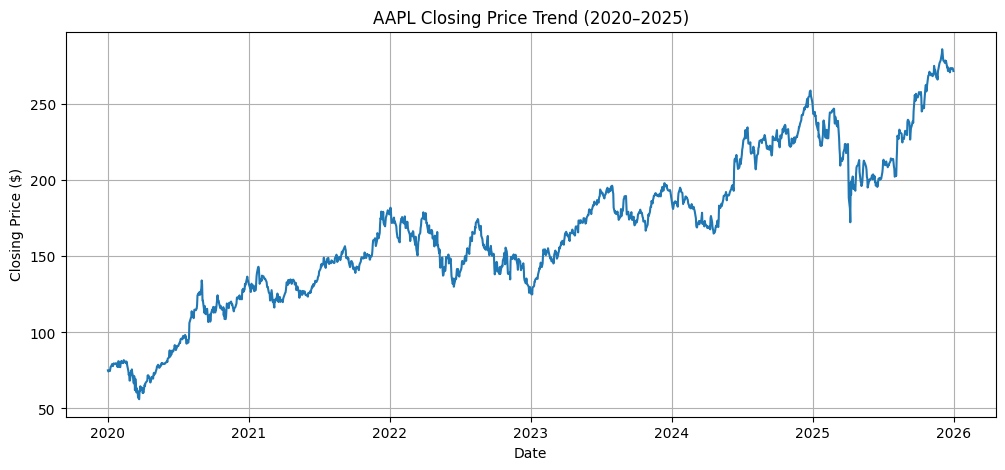

In [14]:
#The closing price was analysed over time to identify the overall direction and major movements in AAPL's stock price.
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(aapl.index, aapl["Close"])

plt.title("AAPL Closing Price Trend (2020–2025)")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.grid(True)

plt.show()

AAPL's closing price shows an overall upward trend from 2020 to 2025, although the stock experienced several periods of decline and recovery. The price rose from around $75 at the beginning of 2020 to above $250 by the end of 2025, indicating substantial long-term growth despite short-term volatility.

Business/analytical interpretation

Overall trend: Upward 📈
Major observation: Long-term growth
Important caveat: The upward trend was not consistent; there were several noticeable declines, particularly around 2020, 2022–2023, and 2025.

In [15]:
#Daily price changes and percentage returns were analysed to understand AAPL's short-term stock performance and volatility.
daily_performance = aapl[["Daily_Change", "Daily_Return", "Daily_Range"]].describe()

daily_performance

Price,Daily_Change,Daily_Return,Daily_Range
count,1508.000000,1507.000000,1508.000000
mean,0.163123,0.105413,3.584278
std,2.511569,2.003665,2.085717
min,-14.279999,-12.864696,0.669998
25%,-1.126249,-0.822525,2.310003
50%,0.157494,0.109474,3.144997
75%,1.529999,1.146409,4.362499
max,26.900009,15.328853,28.720001


In [16]:
#Daily price changes and percentage returns were analysed to understand AAPL's short-term stock performance and volatility.

daily_performance = aapl[["Daily_Change", "Daily_Return", "Daily_Range"]].describe()

daily_performance

Price,Daily_Change,Daily_Return,Daily_Range
count,1508.000000,1507.000000,1508.000000
mean,0.163123,0.105413,3.584278
std,2.511569,2.003665,2.085717
min,-14.279999,-12.864696,0.669998
25%,-1.126249,-0.822525,2.310003
50%,0.157494,0.109474,3.144997
75%,1.529999,1.146409,4.362499
max,26.900009,15.328853,28.720001


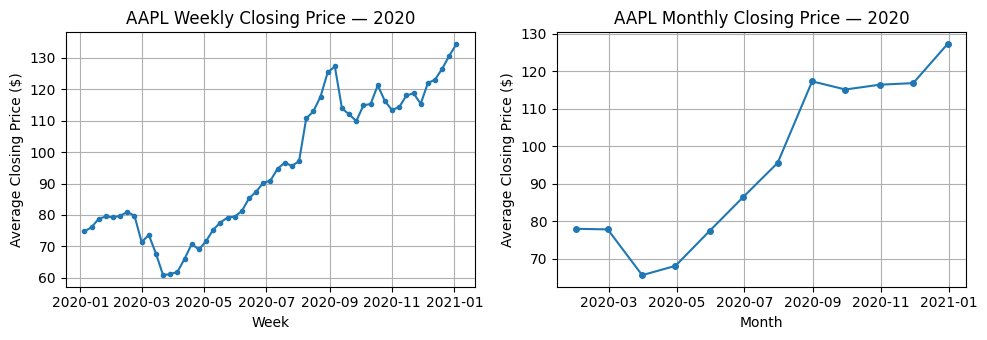

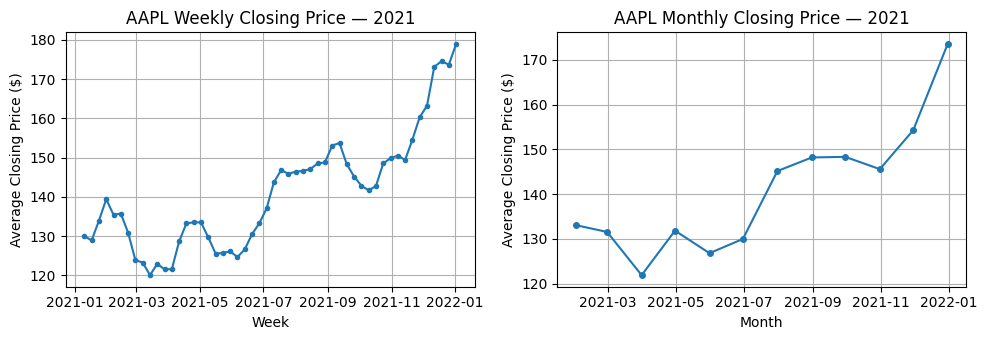

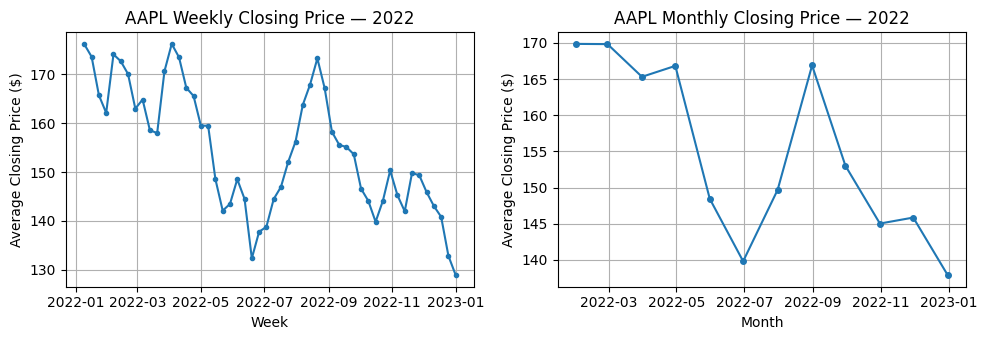

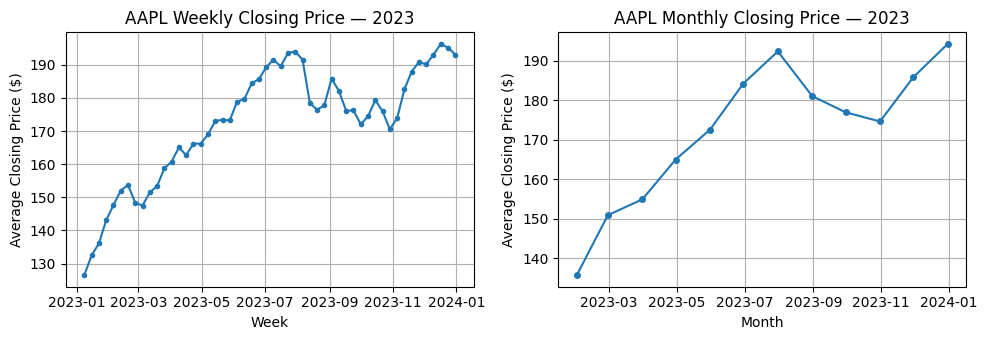

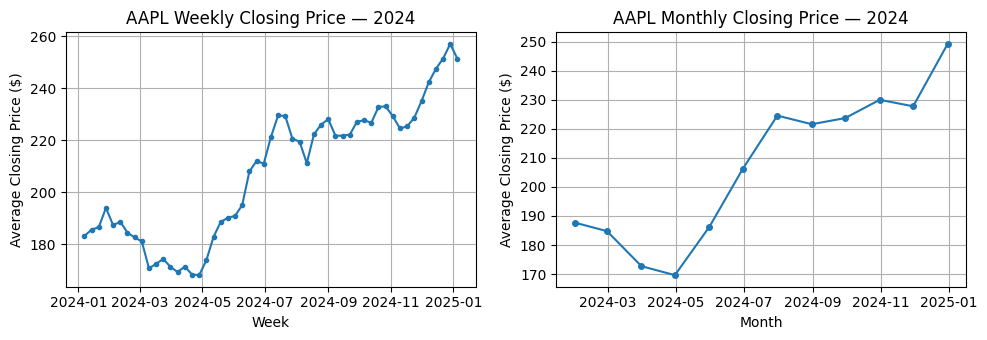

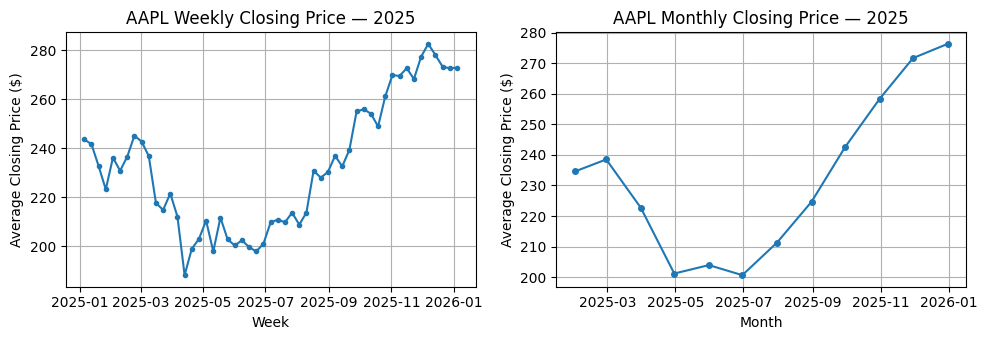

In [17]:
# 2.3 Weekly and Monthly Performance Analysis

# Make sure the data is sorted by date
aapl = aapl.sort_index()

# Analyze each year separately
years = sorted(aapl.index.year.unique())

for year in years:

    # Select one year
    yearly_data = aapl[aapl.index.year == year]

    # Weekly average closing price
    weekly = yearly_data["Close"].resample("W").mean()

    # Monthly average closing price
    monthly = yearly_data["Close"].resample("ME").mean()

    # Create two smaller charts for the year
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

    # Weekly chart
    axes[0].plot(
        weekly.index,
        weekly.values,
        marker="o",
        markersize=3
    )
    axes[0].set_title(f"AAPL Weekly Closing Price — {year}")
    axes[0].set_xlabel("Week")
    axes[0].set_ylabel("Average Closing Price ($)")
    axes[0].grid(True)

    # Monthly chart
    axes[1].plot(
        monthly.index,
        monthly.values,
        marker="o",
        markersize=4
    )
    axes[1].set_title(f"AAPL Monthly Closing Price — {year}")
    axes[1].set_xlabel("Month")
    axes[1].set_ylabel("Average Closing Price ($)")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

Weekly and monthly analysis was performed separately for each year from 2020 to 2025 to examine how AAPL's average closing price changed over shorter time periods. The weekly charts show more detailed price movements, while the monthly charts provide a clearer view of broader yearly patterns.

Key takeaway

The charts show that AAPL's closing price generally increased over the 2020–2025 period, although individual years experienced periods of decline and recovery. The monthly view makes the broader yearly movement easier to identify, while the weekly view captures shorter-term fluctuations.

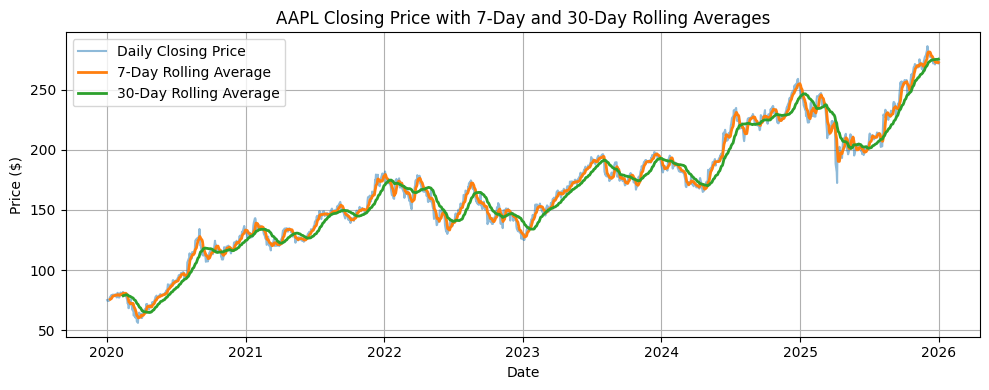

In [18]:
# 2.4 Rolling Averages

# Calculate 7-day and 30-day rolling averages
aapl["7_day_avg"] = aapl["Close"].rolling(window=7).mean()
aapl["30_day_avg"] = aapl["Close"].rolling(window=30).mean()

# Plot the closing price and rolling averages
plt.figure(figsize=(10, 4))

plt.plot(
    aapl.index,
    aapl["Close"],
    label="Daily Closing Price",
    alpha=0.5
)

plt.plot(
    aapl.index,
    aapl["7_day_avg"],
    label="7-Day Rolling Average",
    linewidth=2
)

plt.plot(
    aapl.index,
    aapl["30_day_avg"],
    label="30-Day Rolling Average",
    linewidth=2
)

plt.title("AAPL Closing Price with 7-Day and 30-Day Rolling Averages")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

The 7-day and 30-day rolling averages were used to smooth daily price fluctuations and identify underlying trends. The 7-day average captures short-term movements, while the 30-day average provides a clearer view of the broader trend. Overall, both averages show an upward movement in AAPL's price over the 2020–2025 period, despite several temporary declines.

In [19]:
# 2.5 Percentage Change Analysis

# Calculate daily percentage change in closing price
aapl["daily_pct_change"] = aapl["Close"].pct_change() * 100

# Display the first few results
display(aapl[["Close", "daily_pct_change"]].head(10))

Price,Close,daily_pct_change
Date,,
2020-01-02,75.087502,NaN
2020-01-03,74.357498,-0.972204
2020-01-06,74.949997,0.796825
2020-01-07,74.597504,-0.470305
2020-01-08,75.797501,1.608629
2020-01-09,77.407501,2.124081
2020-01-10,77.582497,0.226070
2020-01-13,79.239998,2.136437
2020-01-14,78.169998,-1.350328


In [20]:
# Largest daily increases
largest_gains = aapl["daily_pct_change"].nlargest(5)

# Largest daily decreases
largest_losses = aapl["daily_pct_change"].nsmallest(5)

print("Largest Daily Gains:")
display(largest_gains)

print("Largest Daily Losses:")
display(largest_losses)

Largest Daily Gains:


,daily_pct_change
Date,
2025-04-09,15.328853
2020-03-13,11.980827
2020-07-31,10.468863
2020-03-24,10.032540
2020-03-02,9.310072


Largest Daily Losses:


,daily_pct_change
Date,
2020-03-16,-12.864696
2020-03-12,-9.875467
2025-04-03,-9.245610
2020-09-03,-8.006086
2020-03-09,-7.909209


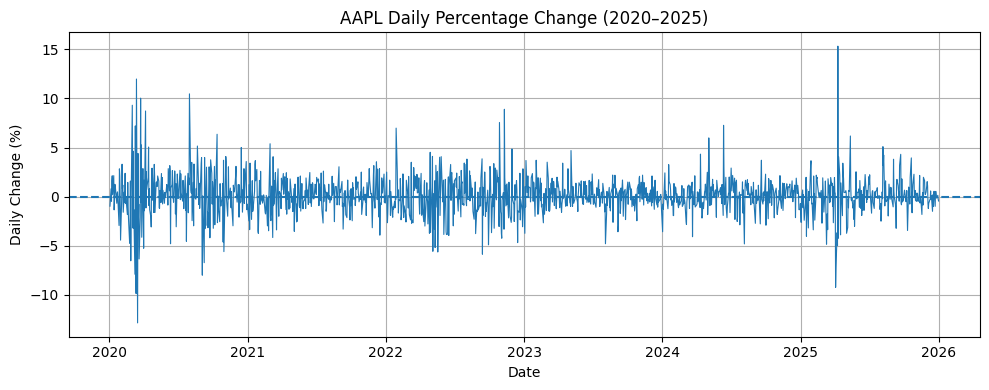

In [21]:
plt.figure(figsize=(10, 4))

plt.plot(
    aapl.index,
    aapl["daily_pct_change"],
    linewidth=0.8
)

plt.axhline(0, linestyle="--")

plt.title("AAPL Daily Percentage Change (2020–2025)")
plt.xlabel("Date")
plt.ylabel("Daily Change (%)")
plt.grid(True)

plt.tight_layout()
plt.show()

The daily percentage change shows that AAPL’s returns fluctuate around 0%, with most daily movements being relatively small. Larger positive and negative spikes indicate periods of higher price volatility, meaning the stock experienced occasional sharp movements.

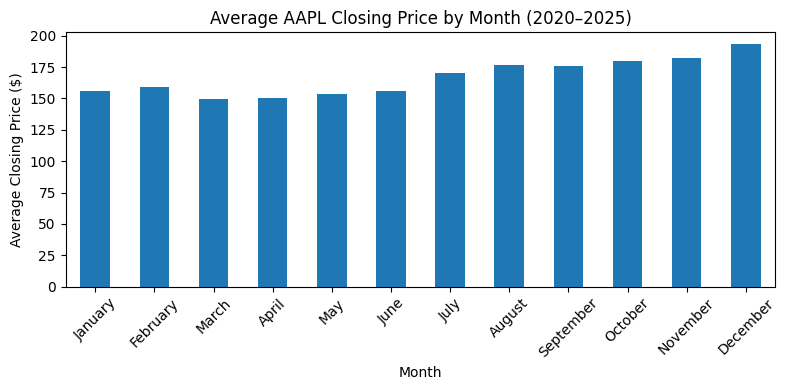

In [22]:
# 2.6 Time-Based Visualization

# Create month column
aapl["Month"] = aapl.index.month_name()

# Calculate average closing price for each month
monthly_avg = aapl.groupby("Month")["Close"].mean()

# Arrange months in calendar order
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_avg = monthly_avg.reindex(month_order)

# Create visualization
plt.figure(figsize=(8, 4))

monthly_avg.plot(kind="bar")

plt.title("Average AAPL Closing Price by Month (2020–2025)")
plt.xlabel("Month")
plt.ylabel("Average Closing Price ($)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
aapl["7_day_avg"] = aapl["Close"].rolling(window=7).mean()
aapl["30_day_avg"] = aapl["Close"].rolling(window=30).mean()

Seven-day and 30-day moving averages were created to smooth price fluctuations and provide short-term and longer-term indicators of AAPL's price trend.

In [24]:
# 3.4 Monthly Returns

monthly_close = aapl["Close"].resample("ME").last()

monthly_returns = monthly_close.pct_change() * 100

monthly_returns.head(10)

,Close
Date,
2020-01-31,NaN
2020-02-29,-11.679759
2020-03-31,-6.976146
2020-04-30,15.537377
2020-05-31,8.216479
2020-06-30,14.738625
2020-07-31,16.513164
2020-08-31,21.437974
2020-09-30,-10.252632


Monthly returns were calculated to measure AAPL's percentage price change from one month to the next, providing a broader view of performance than daily returns.

In [25]:
# 3.5 30-Day Rolling Volatility

aapl["30_day_volatility"] = (
    aapl["daily_pct_change"]
    .rolling(window=30)
    .std()
)

aapl[["daily_pct_change", "30_day_volatility"]].tail()

Price,daily_pct_change,30_day_volatility
Date,,
2025-12-24,0.532388,0.896790
2025-12-26,-0.149740,0.889251
2025-12-29,0.131681,0.888782
2025-12-30,-0.248401,0.889245
2025-12-31,-0.446756,0.824916


A 30-day rolling volatility measure was created using the standard deviation of daily returns. Higher values indicate greater short-term price fluctuations, while lower values indicate more stable price movement.

In [26]:
aapl["Daily_Range"] = aapl["High"] - aapl["Low"]

Daily Price Range was created as the difference between the day's high and low prices. It provides an additional measure of daily market activity and volatility.

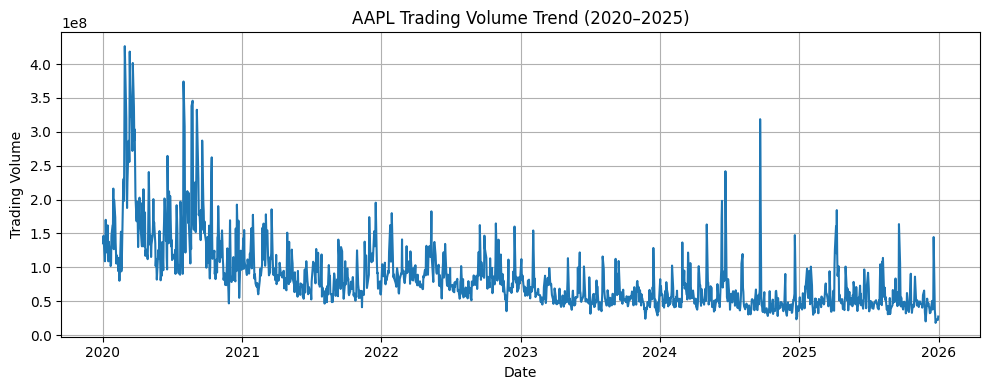

In [27]:
# Trading Volume Trend

plt.figure(figsize=(10, 4))

plt.plot(
    aapl.index,
    aapl["Volume"]
)

plt.title("AAPL Trading Volume Trend (2020–2025)")
plt.xlabel("Date")
plt.ylabel("Trading Volume")

plt.grid(True)

plt.tight_layout()
plt.show()

Trading volume was visualized over time to identify periods of unusually high or low market activity and compare changes in investor trading activity.

In [29]:
start_date = aapl.index.min()
end_date = aapl.index.max()

start_close = aapl["Close"].iloc[0]
end_close = aapl["Close"].iloc[-1]

# Beginning vs end of AAPL closing price

comparison = pd.DataFrame({
    "Period": ["Beginning", "End"],
    "Date": [start_date.date(), end_date.date()],
    "Closing Price ($)": [start_close, end_close]
})

comparison

,Period,Date,Closing Price ($)
0,Beginning,2020-01-02,75.087502
1,End,2025-12-31,271.859985
